In [1]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt

Obtain data from the past five years on Microsoft.

In [35]:
msft = yf.Ticker("MSFT")
df = msft.history(start="2015-10-01", end="2020-09-30")
df = df[["Open","High","Low","Volume"]]

Define the intraday spread as the difference between the high and low price, as a percent of the opening price.

In [36]:
df['Spread'] = 100*(df['High']-df['Low'])/df['Open']
df.head()

,Open,High,Low,Volume,Spread
Date,,,,,
2015-10-01,40.668582,40.668582,39.759787,28657900,2.234637
2015-10-02,40.232377,41.413811,39.914297,41839000,3.727132
2015-10-05,41.577388,42.613414,41.531949,34369300,2.601090
2015-10-06,42.104483,42.876958,42.004515,27017200,2.072089
2015-10-07,42.804254,43.031453,41.759142,27711500,2.972394


Fit a linear model regressing spread on trading volume.

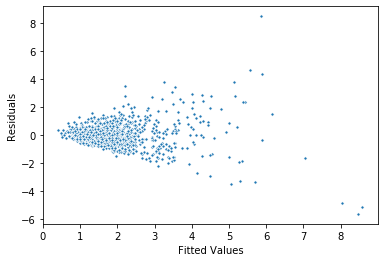

In [37]:
holdlm = sm.OLS.from_formula(formula="Spread~Volume",data=df).fit()

fig,axs = plt.subplots(1,1)
sns.scatterplot(holdlm.fittedvalues,holdlm.resid,s=10)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

Refit using the log of the spread as the response.

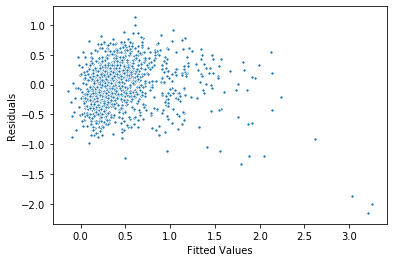

In [38]:
df['LogSpread'] = np.log(df['Spread'])

holdlm2 = sm.OLS.from_formula(formula="LogSpread~Volume",data=df).fit()

fig,axs = plt.subplots(1,1)
sns.scatterplot(holdlm2.fittedvalues,holdlm2.resid,s=10)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

Next, we look at the value of Cook's Distance for each observation.

In [39]:
df["cookd2"] = holdlm2.get_influence().cooks_distance[0]
df.sort_values("cookd2",ascending=False).head(20)

,Open,High,Low,Volume,Spread,LogSpread,cookd2
Date,,,,,,,
2016-06-24,46.220451,47.269015,45.951349,133503000,2.850829,1.047610,0.745154
2015-10-23,47.529995,49.138563,47.484556,135227100,3.479923,1.247010,0.665864
2016-04-22,47.834543,48.313718,46.784045,126834100,3.197842,1.162476,0.484087
2018-12-21,99.358802,100.698188,95.281994,111242100,5.451147,1.695826,0.081694
2016-07-20,52.103562,52.743836,51.528239,89893300,2.333039,0.847172,0.076104
2016-10-21,56.284559,56.443293,55.546924,80032200,1.592567,0.465347,0.065307
2016-01-29,50.073620,50.402992,49.405728,83611700,1.991595,0.688936,0.060646
2018-09-21,110.972976,112.228724,110.495989,71229700,1.561402,0.445584,0.032135
2018-06-15,98.435807,98.455198,97.039415,65738600,1.438281,0.363449,0.022180


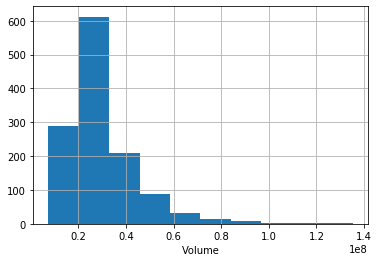

In [40]:
df["Volume"].hist()
plt.xlabel("Volume")
plt.show()

Try transforming the predictor, to reduce the skew.

In [41]:
df['LogVolume'] = np.log(df['Volume'])

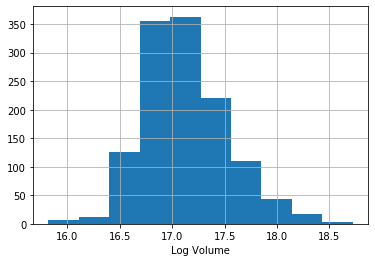

In [42]:
df["LogVolume"].hist()
plt.xlabel("Log Volume")
plt.show()

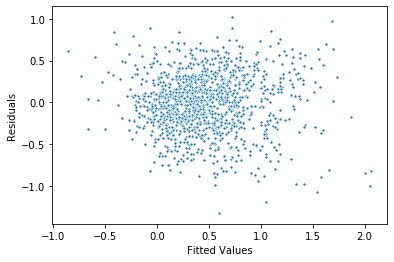

In [43]:
holdlm3 = sm.OLS.from_formula(formula="LogSpread~LogVolume",data=df).fit()

fig,axs = plt.subplots(1,1)
sns.scatterplot(holdlm3.fittedvalues,holdlm3.resid,s=10)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

In [44]:
df["cookd3"] = holdlm3.get_influence().cooks_distance[0]
df.sort_values("cookd3",ascending=False).head(20)

,Open,High,Low,Volume,Spread,LogSpread,cookd2,LogVolume,cookd3
Date,,,,,,,,,
2016-06-24,46.220451,47.269015,45.951349,133503000,2.850829,1.047610,0.745154,18.709635,0.054953
2015-10-23,47.529995,49.138563,47.484556,135227100,3.479923,1.247010,0.665864,18.722466,0.037024
2016-04-22,47.834543,48.313718,46.784045,126834100,3.197842,1.162476,0.484087,18.658390,0.035923
2020-03-13,146.735625,161.070953,140.000704,92727400,14.359327,2.664400,0.016847,18.345175,0.031872
2016-10-21,56.284559,56.443293,55.546924,80032200,1.592567,0.465347,0.065307,18.197940,0.030389
2016-01-29,50.073620,50.402992,49.405728,83611700,1.991595,0.688936,0.060646,18.241694,0.022618
2016-07-20,52.103562,52.743836,51.528239,89893300,2.333039,0.847172,0.076104,18.314134,0.020721
2018-09-21,110.972976,112.228724,110.495989,71229700,1.561402,0.445584,0.032135,18.081420,0.020560
2018-06-15,98.435807,98.455198,97.039415,65738600,1.438281,0.363449,0.022180,18.001197,0.017789
